In [1]:
import numpy as np
import pickle
import time

import matplotlib.pyplot as plt
from src.CPL_metrics.DT import DT
from src.CPL_metrics.LTM import precompute, LTM
from src.CPL_metrics.HCC_2 import HCC_2
from src.CPL_metrics.calibrate_CPL import calibrate_CPL
from src.CPL_metrics.uncalibrate_CPL import uncalibrate_CPL


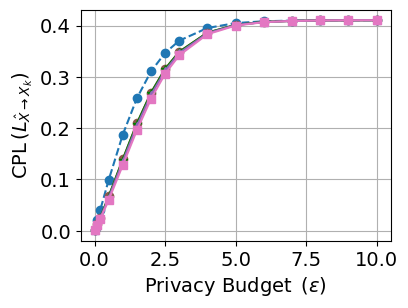

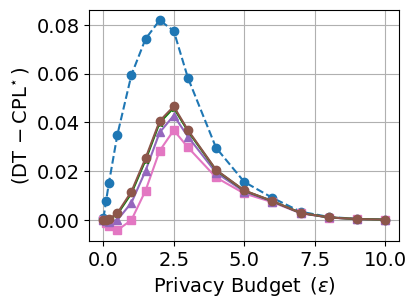

In [2]:
EPS_LIST = [0.01, 0.1, 0.2, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 7, 8, 9, 10]
EPS_0_LIST = [0.01, 0.1, 0.5, 1]
ALPHBET_SIZE = 10

CPL_estimate_uncalibrated = []
CPL_estimate_calibrated = []
CPL_star = []

with open(f'datasets/synthetic_datasets/synthetic_CMF_{ALPHBET_SIZE}.pkl', 'rb') as file:
    CMF = pickle.load(file)

for eps in EPS_LIST:
    CPL_star.append(HCC_2(eps, CMF)[0])

for eps in EPS_LIST:
    CPL_estimate_uncalibrated.append(Algo2_privacy_leakage_final(eps, CMF = CMF)[0])

for eps_0 in EPS_0_LIST:
    CPL_estimate_calibrated_inner = []
    for eps in EPS_LIST:
        CPL_estimate_calibrated_inner.append(calibrate_CPL(eps_0=eps_0, eps = eps, CMF = CMF))
    CPL_estimate_calibrated.append(CPL_estimate_calibrated_inner)

plt.figure(figsize=(4, 3))
plt.plot(EPS_LIST, np.array(CPL_estimate_uncalibrated), '--o')
plt.plot(EPS_LIST, np.array(CPL_estimate_calibrated[0]), '-o', color='tab:brown')
plt.plot(EPS_LIST, np.array(CPL_estimate_calibrated[1]), '-*g')
plt.plot(EPS_LIST, np.array(CPL_estimate_calibrated[2]), '-^', color='tab:purple')
plt.plot(EPS_LIST, np.array(CPL_estimate_calibrated[3]), '-s', color='tab:pink')
plt.xlabel(r"$\operatorname{Privacy \text{ } Budget}$ $(\epsilon)$", fontsize=14)
plt.ylabel(r"$\operatorname{CPL } (L_{\hat{X}\rightarrow X_k})$", fontsize=14)
# plt.title(r"$\text{Histogram of a Random Variable}$", fontsize=14)
plt.tick_params(axis='x', labelsize=14)  # Font size for x-axis numbers
plt.tick_params(axis='y', labelsize=14)  # Font size for y-axis numbers
ax = plt.grid(True)
plt.show()

plt.figure(figsize=(4, 3))
plt.plot(EPS_LIST, np.array(CPL_estimate_uncalibrated) - np.array(CPL_star), '--o')
plt.plot(EPS_LIST, np.array(CPL_estimate_calibrated[3]) - np.array(CPL_star), '-s', color='tab:pink')
plt.plot(EPS_LIST, np.array(CPL_estimate_calibrated[2]) - np.array(CPL_star), '-^', color='tab:purple')
plt.plot(EPS_LIST, np.array(CPL_estimate_calibrated[1]) - np.array(CPL_star), '-*g')
plt.plot(EPS_LIST, np.array(CPL_estimate_calibrated[0]) - np.array(CPL_star), '-o', color='tab:brown')
plt.xlabel(r"$\operatorname{Privacy \text{ } Budget}$ $(\epsilon)$", fontsize=14)
plt.ylabel(r"$(\operatorname{DT} - \operatorname{CPL}^\star)$", fontsize=14)
plt.tick_params(axis='x', labelsize=14) 
plt.tick_params(axis='y', labelsize=14)  
ax = plt.grid(True)
plt.show()